# Lotto Exploratory Data Analysis (EDA)

This notebook visually inspects the historical lotto dataset.

The goal is not only to check simple frequencies, but also to see whether the real data looks materially different from a uniform process, whether there are visible time trends, and whether strong dependence appears between numbers.

Topics covered:

1. Main-number frequency vs. uniform expectation
2. Bonus-number frequency vs. uniform expectation
3. Odd-even distribution
4. Low-high distribution
5. Distribution of the number sum
6. Time-trend inspection
7. Pairwise correlation inspection

### 1. Library Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import (
    build_one_hot_matrix,
    build_upper_triangle_mask,
    calculate_bonus_frequency,
    calculate_correlation_matrix,
    calculate_expected_bonus_frequency,
    calculate_expected_main_frequency,
    calculate_low_high_distribution,
    calculate_number_frequency,
    calculate_odd_even_distribution,
    calculate_round_sum_trend,
    calculate_sum_distribution,
    categorize_number_ranges,
)
from src.config import PROCESSED_LOTTO_FILE
from src.visualization import (
    plot_bonus_number_frequency,
    plot_correlation_heatmap,
    plot_count_distribution,
    plot_main_number_frequency,
    plot_sum_distribution,
    plot_sum_over_time,
)

In [2]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### 2. Load the Data

In [3]:
df = pd.read_csv(PROCESSED_LOTTO_FILE)
df.head()

,row_id,round,n1,n2,n3,n4,n5,n6,bonus,rank_text,winner_count,prize_amount,numbers,sum_main,odd_count,even_count,low_count,high_count
0,1214,1,10,23,29,33,37,40,16,1등,0,0,"10,23,29,33,37,40",172,4,2,1,5
1,1213,2,9,13,21,25,32,42,2,1등,1,2002006800,"9,13,21,25,32,42",142,4,2,3,3
2,1212,3,11,16,19,21,27,31,30,1등,1,2000000000,"11,16,19,21,27,31",125,5,1,4,2
3,1211,4,14,27,30,31,40,42,2,1등,0,0,"14,27,30,31,40,42",184,2,4,1,5
4,1210,5,16,24,29,40,41,42,3,1등,0,0,"16,24,29,40,41,42",192,2,4,1,5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   row_id        1214 non-null   int64
 1   round         1214 non-null   int64
 2   n1            1214 non-null   int64
 3   n2            1214 non-null   int64
 4   n3            1214 non-null   int64
 5   n4            1214 non-null   int64
 6   n5            1214 non-null   int64
 7   n6            1214 non-null   int64
 8   bonus         1214 non-null   int64
 9   rank_text     1214 non-null   str  
 10  winner_count  1214 non-null   int64
 11  prize_amount  1214 non-null   int64
 12  numbers       1214 non-null   str  
 13  sum_main      1214 non-null   int64
 14  odd_count     1214 non-null   int64
 15  even_count    1214 non-null   int64
 16  low_count     1214 non-null   int64
 17  high_count    1214 non-null   int64
dtypes: int64(16), str(2)
memory usage: 170.8 KB


In [5]:
df.describe()

,row_id,round,n1,n2,n3,n4,n5,n6,bonus,winner_count,prize_amount,sum_main,odd_count,even_count,low_count,high_count
count,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1.214000e+03,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000
mean,607.500000,607.500000,6.742998,13.071664,19.934926,26.228995,32.830313,39.436573,22.317957,8.429160,2.640828e+09,138.245470,3.074135,2.925865,2.940692,3.059308
std,350.595921,350.595921,5.410427,6.879409,7.406458,7.528913,6.811140,5.309747,13.165485,5.130242,2.353201e+09,30.813254,1.153984,1.153984,1.178864,1.178864
min,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,9.000000,17.000000,1.000000,0.000000,0.000000e+00,48.000000,0.000000,0.000000,0.000000,0.000000
25%,304.250000,304.250000,3.000000,8.000000,14.000000,21.000000,28.000000,37.000000,11.000000,5.000000,1.568108e+09,116.250000,2.000000,2.000000,2.000000,2.000000
50%,607.500000,607.500000,5.000000,12.000000,19.000000,27.000000,34.000000,41.000000,23.000000,8.000000,2.078125e+09,138.000000,3.000000,3.000000,3.000000,3.000000
75%,910.750000,910.750000,10.000000,17.000000,25.000000,32.000000,38.000000,44.000000,33.000000,11.000000,2.959228e+09,160.750000,4.000000,4.000000,4.000000,4.000000
max,1214.000000,1214.000000,35.000000,37.000000,40.000000,43.000000,44.000000,45.000000,45.000000,63.000000,4.072296e+10,238.000000,6.000000,6.000000,6.000000,6.000000


In [6]:
df["round"].min(), df["round"].max()

(np.int64(1), np.int64(1214))

### 3. Main-Number Frequency

This section checks how often each main number appeared over the full history.
The red dashed line shows the expected frequency under a perfectly uniform process.

In [8]:
number_cols = ["n1", "n2", "n3", "n4", "n5", "n6"]
bonus_col = "bonus"

In [9]:
number_freq = calculate_number_frequency(df, number_cols=number_cols)
number_freq

1     167
2     152
3     169
4     159
5     153
6     163
7     168
8     155
9     133
10    159
11    164
12    177
13    174
14    169
15    163
16    166
17    169
18    172
19    166
20    167
21    164
22    141
23    146
24    163
25    150
26    164
27    180
28    151
29    152
30    156
31    164
32    141
33    173
34    181
35    161
36    162
37    171
38    169
39    165
40    172
41    147
42    153
43    162
44    160
45    171
Name: count, dtype: int64

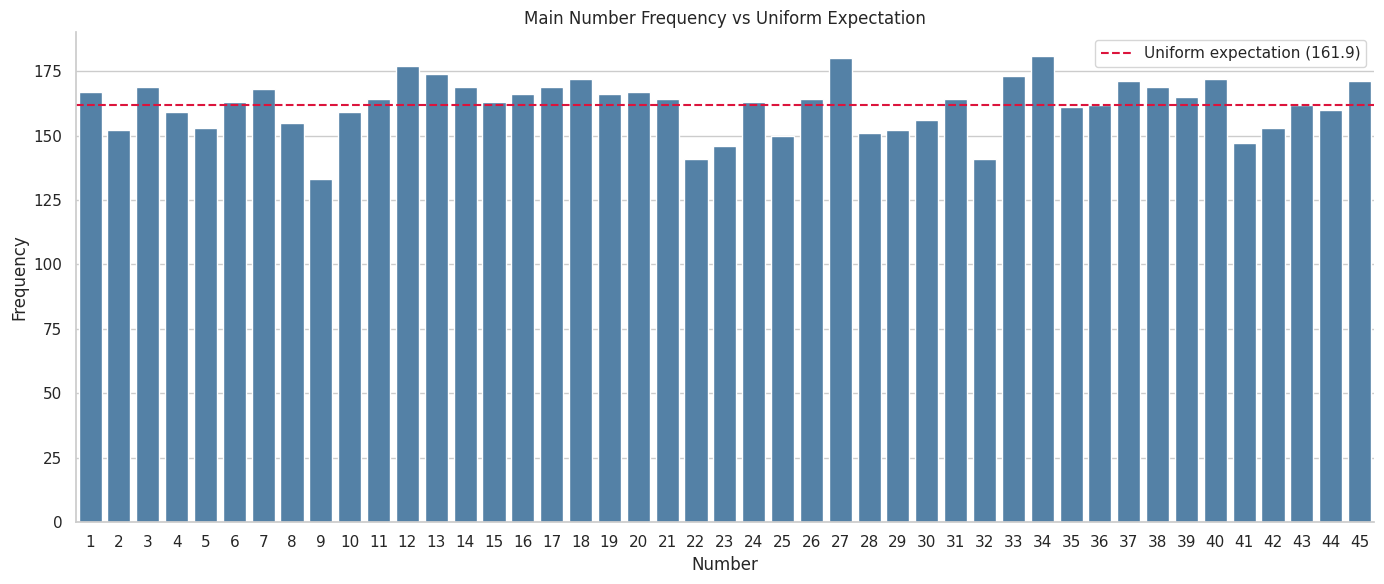

In [10]:
expected_freq = calculate_expected_main_frequency(df)
plot_main_number_frequency(number_freq, expected_freq)

### 4. Bonus-Number Frequency

This section checks whether bonus numbers also show any long-run concentration on specific values.

In [11]:
bonus_freq = calculate_bonus_frequency(df, bonus_col=bonus_col)
bonus_freq

bonus
1     32
2     36
3     31
4     35
5     25
6     34
7     32
8     24
9     25
10    28
11    26
12    27
13    27
14    23
15    25
16    28
17    33
18    19
19    22
20    29
21    25
22    20
23    21
24    33
25    21
26    31
27    31
28    25
29    17
30    32
31    31
32    34
33    31
34    23
35    30
36    24
37    26
38    30
39    24
40    22
41    17
42    25
43    35
44    24
45    21
Name: count, dtype: int64

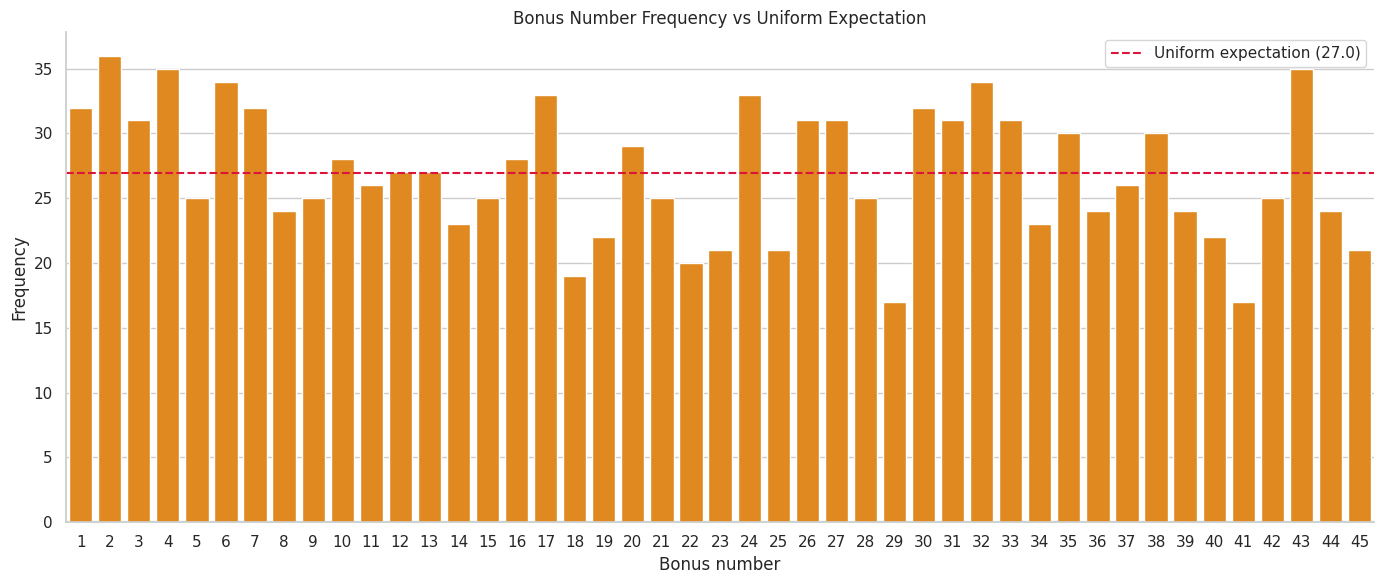

In [12]:
expected_bonus_freq = calculate_expected_bonus_frequency(df)
plot_bonus_number_frequency(bonus_freq, expected_bonus_freq)

### 5. Odd-Even Pattern

In [13]:
calculate_odd_even_distribution(df)

odd_count
0     17
1     81
2    270
3    406
4    325
5     97
6     18
Name: count, dtype: int64

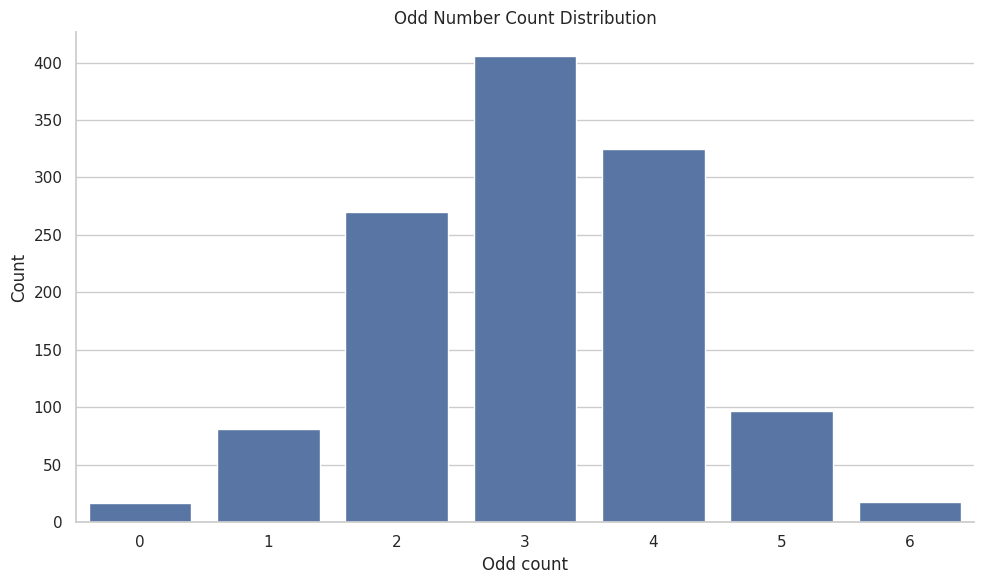

In [14]:
plot_count_distribution(df["odd_count"], title="Odd Number Count Distribution", xlabel="Odd count")

### 6. Low-High Split

- Low: 1-22
- High: 23-45

In [15]:
calculate_low_high_distribution(df)

low_count
0     16
1    112
2    307
3    398
4    271
5     94
6     16
Name: count, dtype: int64

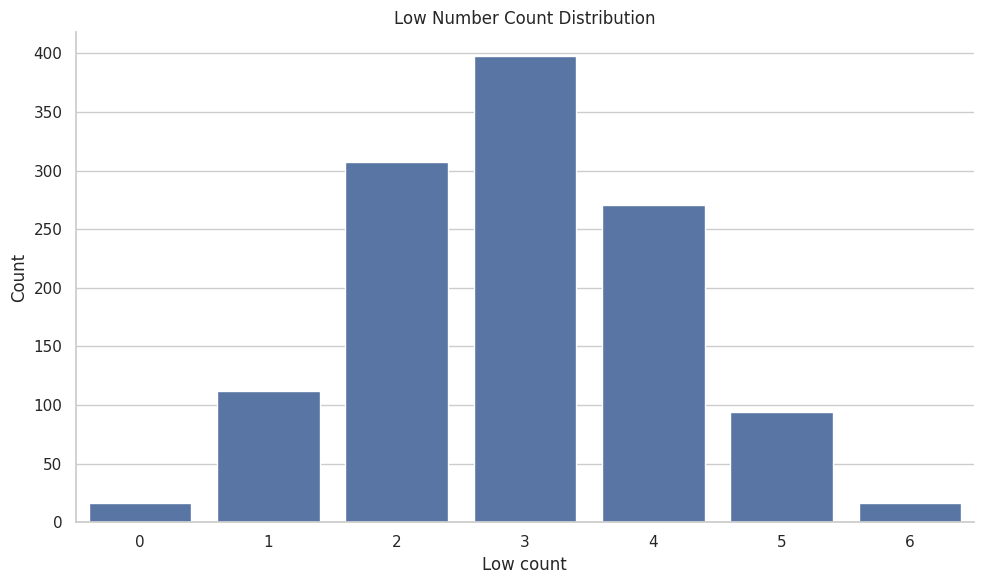

In [16]:
plot_count_distribution(df["low_count"], title="Low Number Count Distribution", xlabel="Low count")

### 7. Sum Distribution

This section looks at the range where the sum of the six main numbers usually falls.
A KDE curve and the mean line are added to make the center and spread easier to interpret.

In [17]:
calculate_sum_distribution(df).describe()

count    1214.000000
mean      138.245470
std        30.813254
min        48.000000
25%       116.250000
50%       138.000000
75%       160.750000
max       238.000000
Name: sum_main, dtype: float64

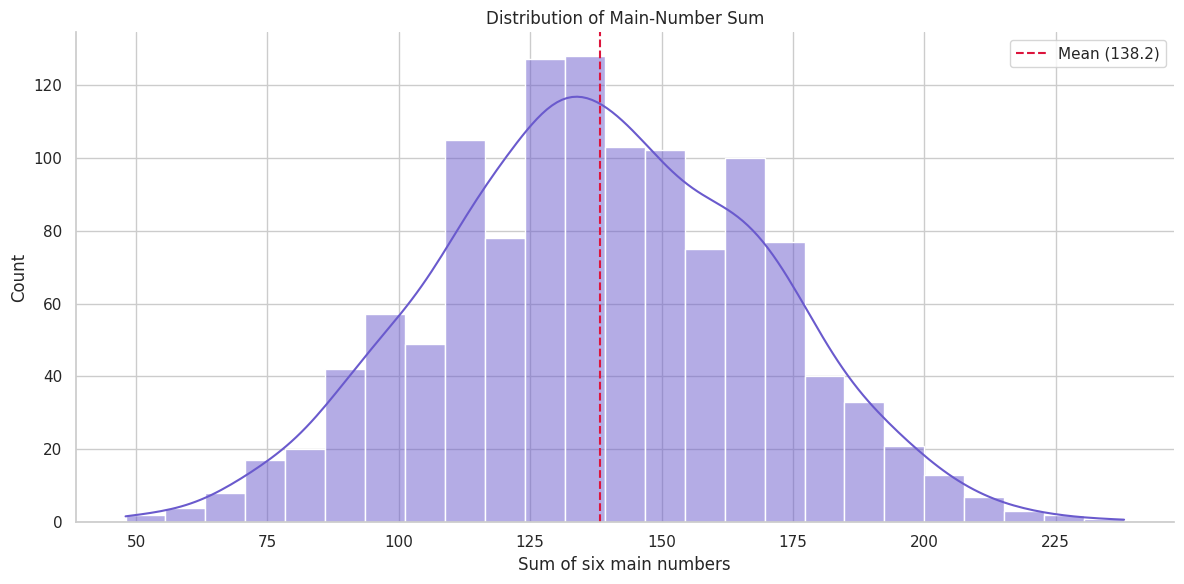

In [18]:
plot_sum_distribution(calculate_sum_distribution(df))

### 8. Time-Trend Inspection

This section checks whether the sum of the main numbers shows any structural trend over time.
It plots individual rounds together with a 20-round rolling mean to make long-run drift easier to see.

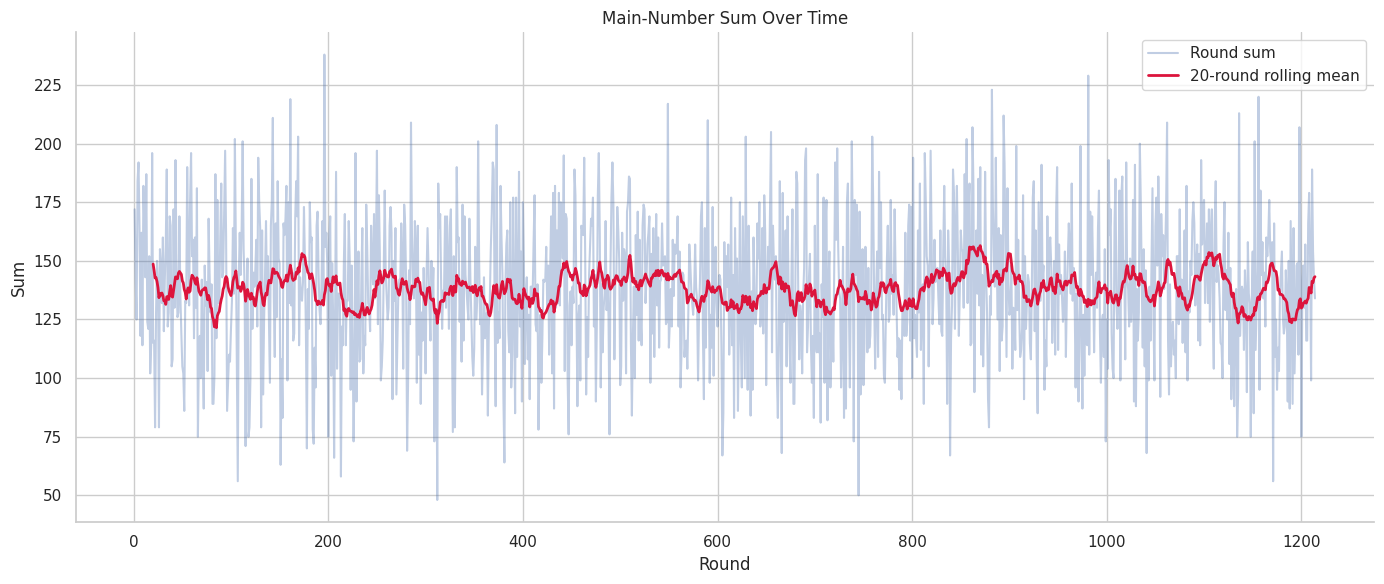

In [19]:
sum_trend = calculate_round_sum_trend(df)
rolling_sum = sum_trend["sum_main"].rolling(20).mean()
plot_sum_over_time(sum_trend["round"], sum_trend["sum_main"], rolling_sum)

### 9. Number-Appearance Heatmap

In [20]:
one_hot = build_one_hot_matrix(df, number_cols=number_cols)

In [21]:
one_hot.sum()

1     167
2     152
3     169
4     159
5     153
6     163
7     168
8     155
9     133
10    159
11    164
12    177
13    174
14    169
15    163
16    166
17    169
18    172
19    166
20    167
21    164
22    141
23    146
24    163
25    150
26    164
27    180
28    151
29    152
30    156
31    164
32    141
33    173
34    181
35    161
36    162
37    171
38    169
39    165
40    172
41    147
42    153
43    162
44    160
45    171
dtype: int64

### 10. Pairwise Correlation

This heatmap shows pairwise correlations among one-hot encoded numbers.
If strong positive or negative correlations are mostly absent, it supports the interpretation that dependence across numbers is limited.

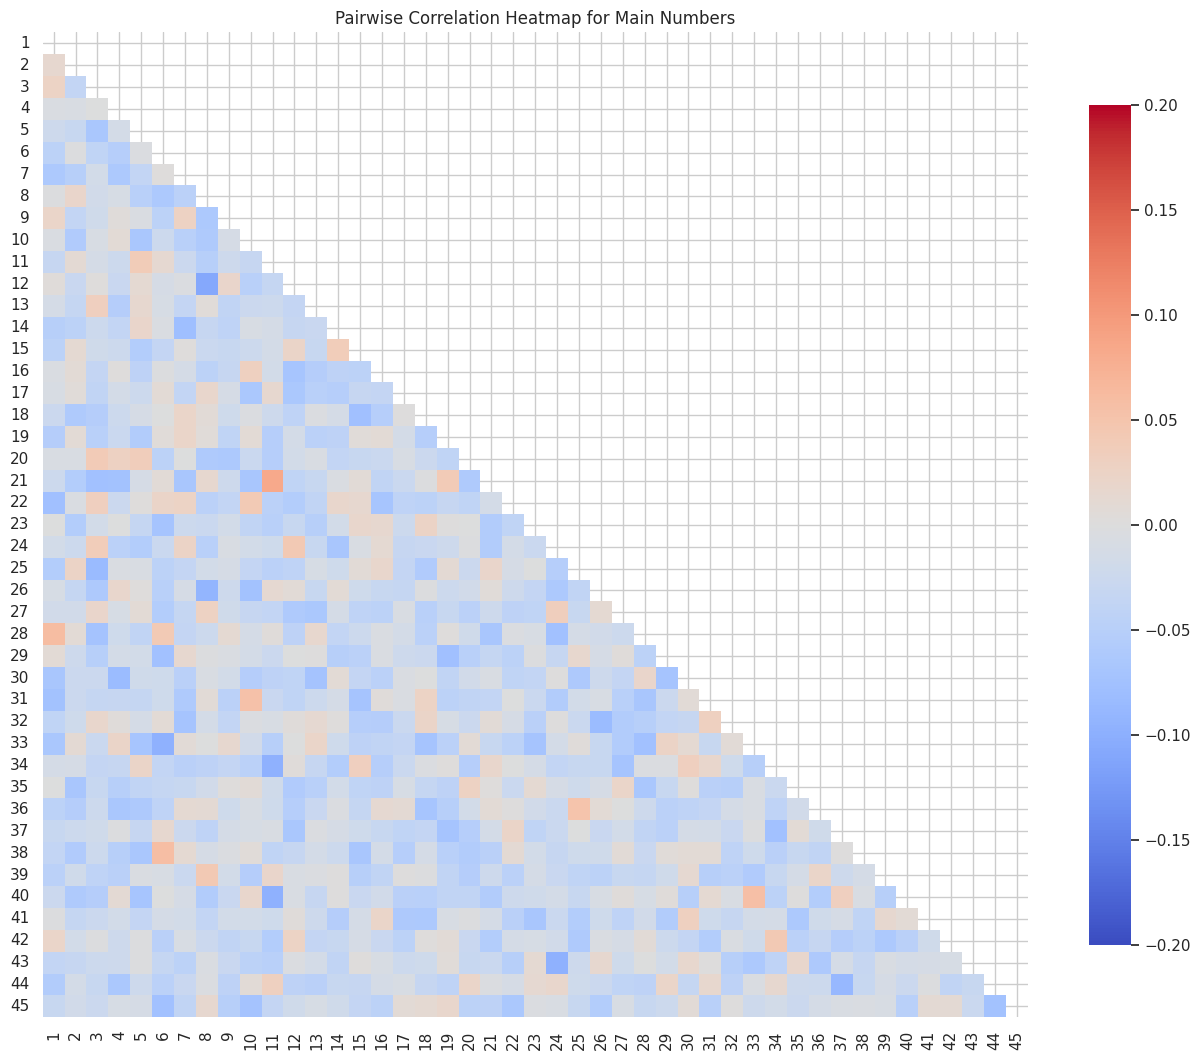

In [22]:
corr = calculate_correlation_matrix(one_hot)
mask = build_upper_triangle_mask(corr)
plot_correlation_heatmap(corr, mask=mask)

### 11. Appearance Counts

In [23]:
# 최댓값 10개
number_freq.sort_values(ascending=False).head(10)

34    181
27    180
12    177
13    174
33    173
18    172
40    172
37    171
45    171
17    169
Name: count, dtype: int64

In [24]:
# 최솟값 10개
number_freq.sort_values().head(10)

9     133
22    141
32    141
23    146
41    147
25    150
28    151
29    152
2     152
5     153
Name: count, dtype: int64

### 12. Range-Based Distribution

In [25]:
binned = categorize_number_ranges(df, number_cols=number_cols)
pd.Series(binned).value_counts()

11-20    1687
31-40    1659
1-10     1578
21-30    1567
41-45     793
Name: count, dtype: int64

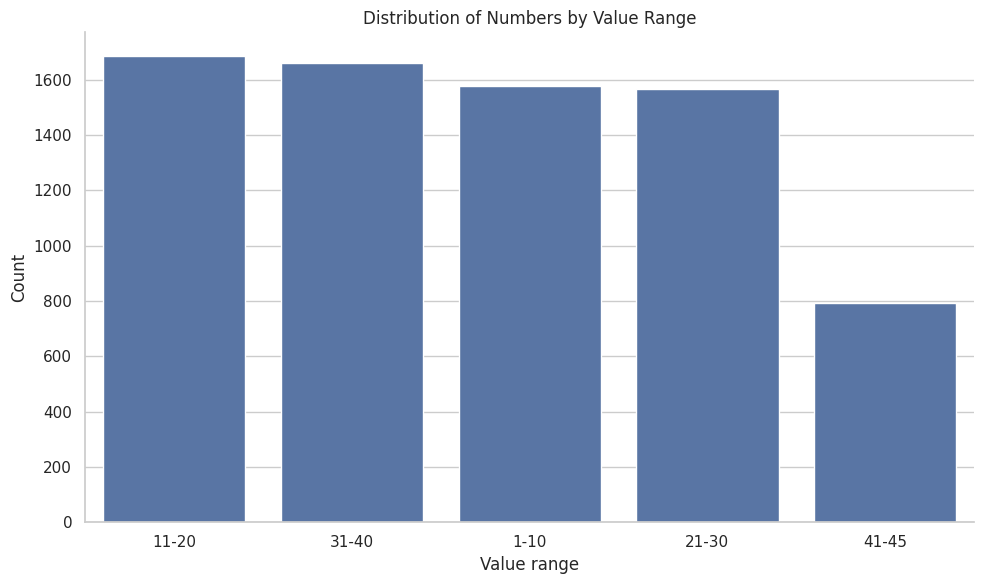

In [26]:
plt.figure(figsize=(10,6))
sns.countplot(x=binned, order=binned.value_counts().index)
plt.title("Distribution of Numbers by Value Range")
plt.xlabel("Value range")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 13. EDA Summary

The purpose of this stage is to gather visual evidence for the following questions:

- Do some numbers appear far more or less often than expected over the long run?
- Do the sum, odd-even mix, or range-based counts show structural bias?
- Is there any visible long-run drift over time?
- Are strong correlations visible between numbers?

The next notebook tests these observations more rigorously with statistical tests and random simulations.